In [140]:
import polars as pl
import pandas as pd
import numpy as np
import altair as alt
import pyarrow
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from func.UsefulFunctions import *
import geopandas as gpd

This jupyter notebook inspects the contents of the artists (that is individual performers/creatives) to gain an understanding of their statistics. The sou

In [141]:

artistDF = pl.read_parquet("./Data/personMusicBrainzData.parquet")
#De-duplicate the data
artistDF = artistDF.unique()

#How many unique artists are there now. This data is now based off of the number of unique

num_of_ids = artistDF.select(
    pl.col("id")
).unique().count().item(0,0)
print(f"There are {num_of_ids} unique IDs in the dataset (that is a snapshot from 18/07/2026).")

There are 1574608 unique IDs in the dataset (that is a snapshot from 18/07/2026).


In [142]:
#How many people do not have a name in this dataset?
num_people_with_no_names = artistDF.select(
    pl.col("name"),
    pl.col("id")
).unique().null_count()
print(num_people_with_no_names)
print(f"There are {num_people_with_no_names.item(0,0)} entities with no name, and {num_people_with_no_names.item(0,1)} entities with no ids.")

shape: (1, 2)
┌──────┬─────┐
│ name ┆ id  │
│ ---  ┆ --- │
│ u32  ┆ u32 │
╞══════╪═════╡
│ 0    ┆ 0   │
└──────┴─────┘
There are 0 entities with no name, and 0 entities with no ids.


In [143]:
#check if there are any duplicates in ids
ids = artistDF.select(
    pl.col("id")
).is_duplicated()
print(ids.value_counts())

print("Based off of the lack of trues in the is_duplicated function. All rows are unique after the deduplication ")

shape: (1, 2)
┌───────┬─────────┐
│       ┆ count   │
│ ---   ┆ ---     │
│ bool  ┆ u32     │
╞═══════╪═════════╡
│ false ┆ 1574608 │
└───────┴─────────┘
Based off of the lack of trues in the is_duplicated function. All rows are unique after the deduplication 


In [144]:
#Do a count for the countries for the dataset.
countryCount = artistDF.select(pl.col("country").value_counts(sort=True)).unnest("country")
print(countryCount)

shape: (252, 2)
┌─────────┬────────┐
│ country ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ null    ┆ 655691 │
│ US      ┆ 220745 │
│ GB      ┆ 81004  │
│ JP      ┆ 75389  │
│ DE      ┆ 71965  │
│ …       ┆ …      │
│ PN      ┆ 1      │
│ NU      ┆ 1      │
│ BV      ┆ 1      │
│ AN      ┆ 1      │
│ HM      ┆ 1      │
└─────────┴────────┘


The most common country for individual performers (outside of null which trumps it) is US followed by GB and Japan.

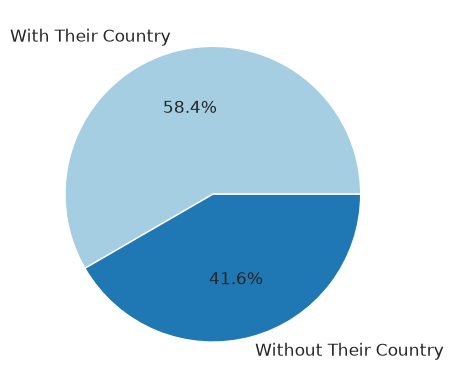

In [145]:
#Make a pie chart for people who have a country and does who don't
noCountry = (artistDF
             .filter(
    pl.col("country").is_null(),
    ).select(pl.col("id")).drop_nulls().unique())
hasCountry = (artistDF
              .filter(
    pl.col("country").is_not_null(),
).select(pl.col("id")).drop_nulls().unique())
plt.rc('font', size=12)
makePieChart(["With Their Country", "Without Their Country"], [len(hasCountry),len(noCountry)],
             "Country Known vs Unknown on MusicBrainz for Groups", "Paired")

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

,ISO_A2_EH,geometry
0,ID,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,MY,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


country          str
count         uint32
log_count    float64
dtype: object


,ISO_A2_EH,count,log_count
0,US,220745,12.304763
1,GB,81004,11.302254
2,JP,75389,11.230417
3,DE,71965,11.183935
4,FR,45674,10.729284
...,...,...,...
246,PN,1,0.000000
247,NU,1,0.000000
248,BV,1,0.000000
249,AN,1,0.000000


,ISO_A2_EH,geometry,count,log_count
0,ID,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",4393.0,8.387768
1,MY,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",1023.0,6.930495
2,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",1921.0,7.560601
3,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",172.0,5.147494
4,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",971.0,6.878326


<Axes: >

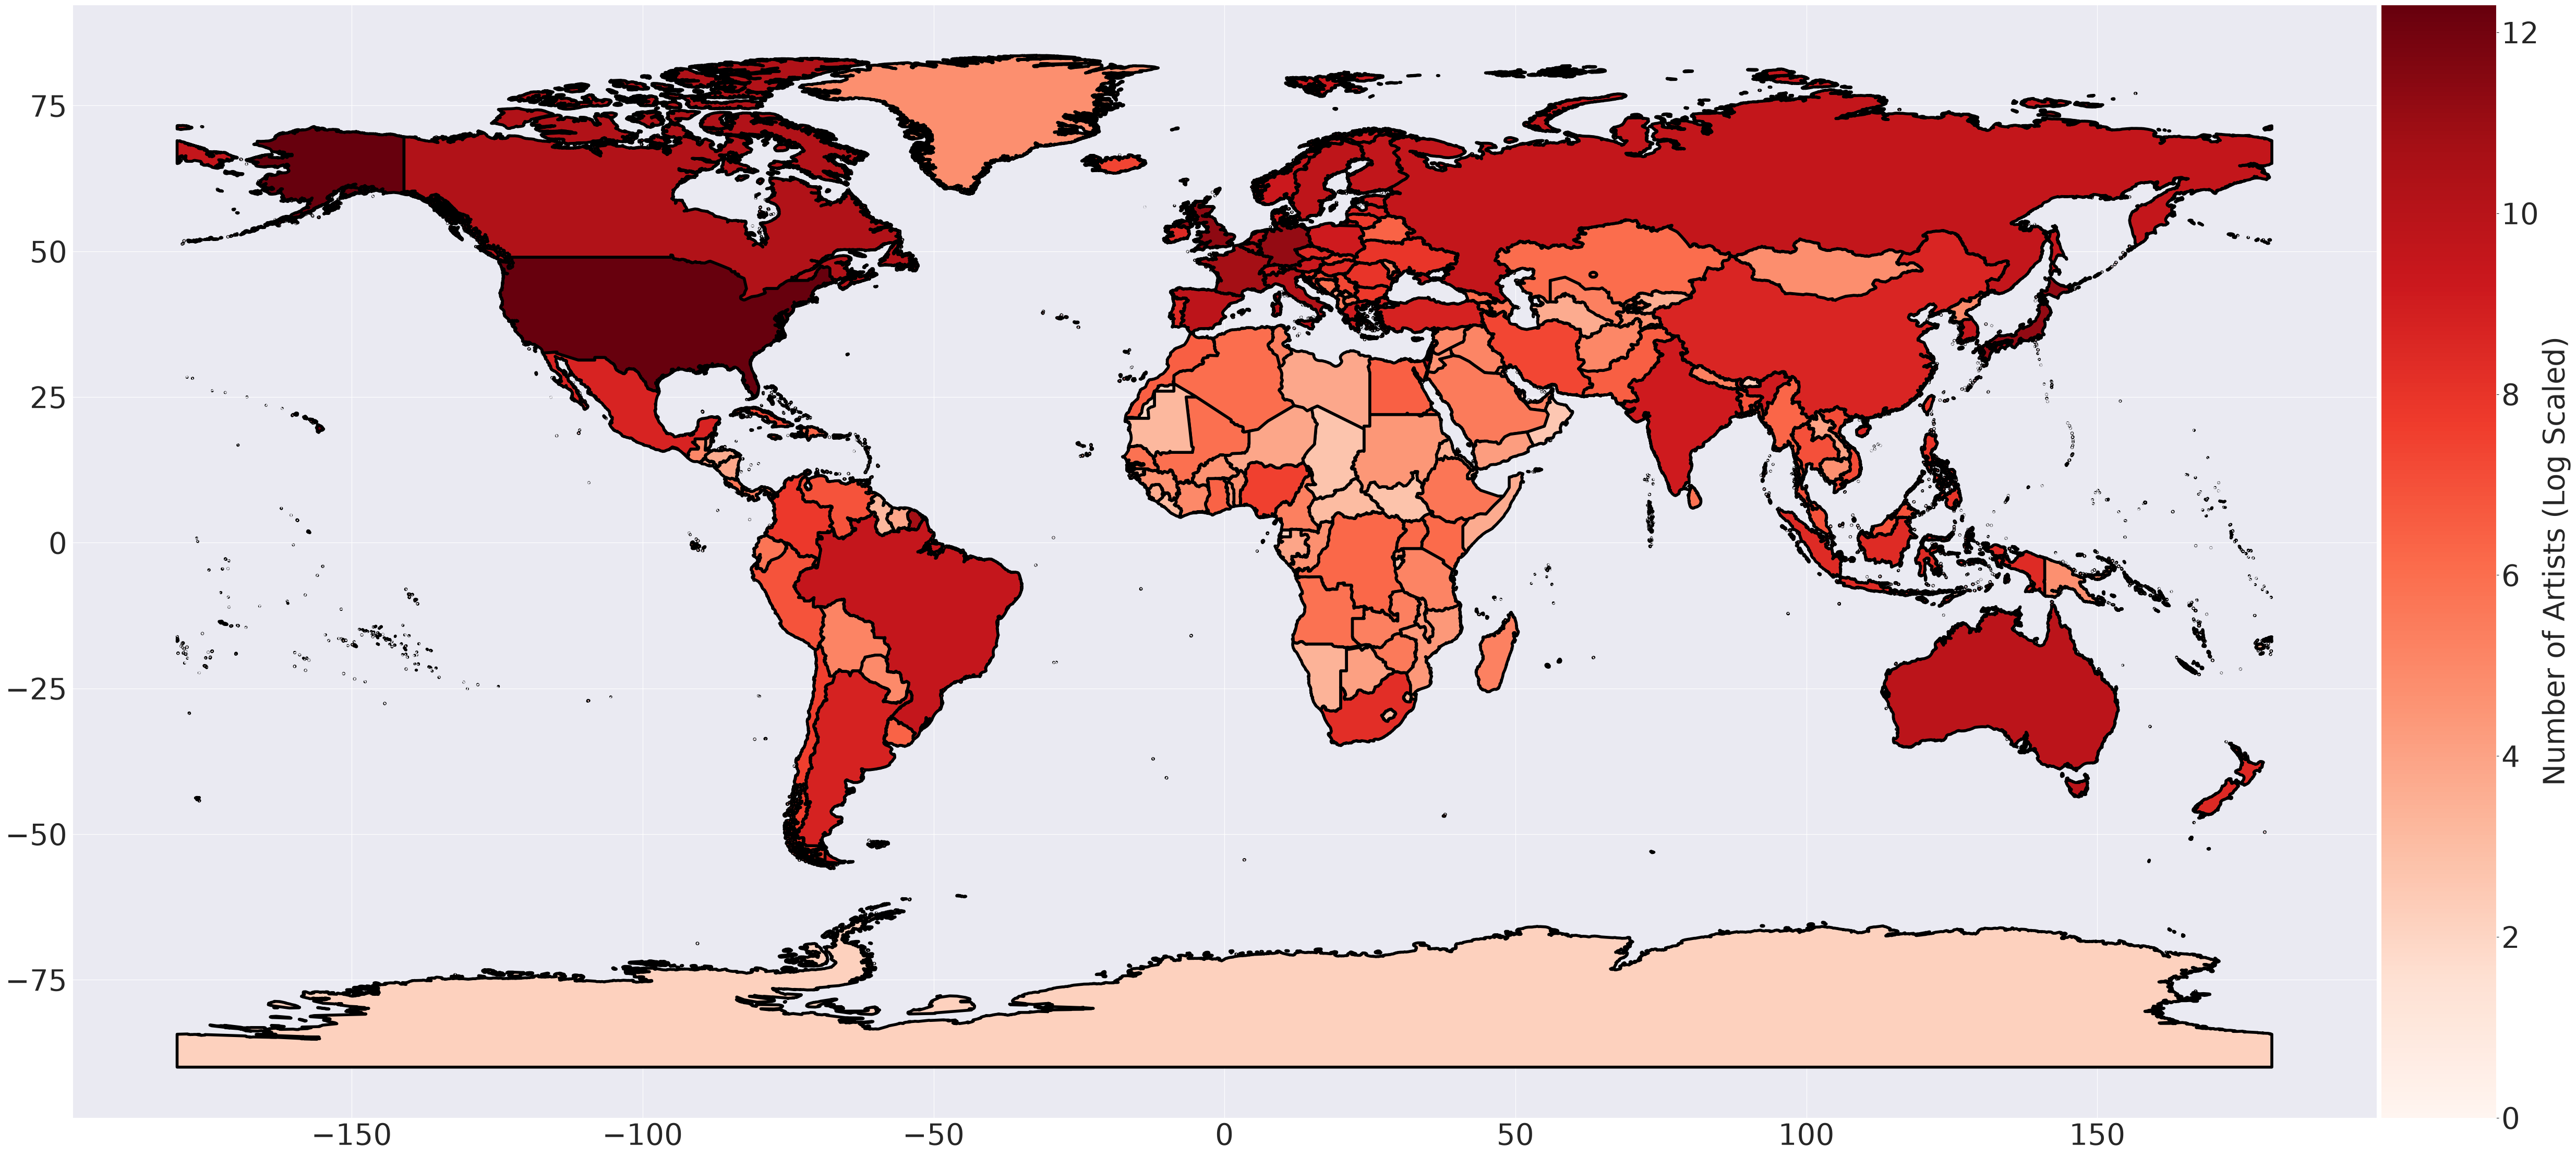

In [146]:
#Create a heatmap for the countries of artists on MusicbRAINZ

worldMap = gpd.read_file("./mapData/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")
display(worldMap.columns)
#display(worldMap[worldMap['ISO_A3'] == "FRA"])
worldMap = worldMap[['ISO_A2_EH','geometry']]
display(worldMap.head())
#display(worldMap[worldMap["ISO_A2"] == "FR"])
countryCountPandas = countryCount.drop_nulls().to_pandas()
countryCountPandas["log_count"] = np.log(countryCountPandas["count"])
print(countryCountPandas.dtypes)
countryCountPandas = countryCountPandas.rename(columns={"country":"ISO_A2_EH"})
display(countryCountPandas)
preppedCountryData = worldMap.merge(countryCountPandas, on='ISO_A2_EH', how='left')
display(preppedCountryData.head())
#display(preppedCountryData[preppedCountryData["ISO_A2_eh"] == "FR"])
plt.rc('font', size=40)
fig, axMap = plt.subplots(figsize=(60,60))

divider = make_axes_locatable(axMap)
cax = divider.append_axes("right", size="5%", pad=0.05)
cax.tick_params(labelsize=40)
preppedCountryData.plot(column="log_count",
                        cmap="Reds",
                        edgecolor="black",
                        linewidth=4,
                        ax = axMap,
                        cax = cax,
                        legend=True,
                        legend_kwds={"label":"Number of Artists (Log Scaled)"},)


shape: (6, 2)
┌────────────────┬────────┐
│ gender         ┆ count  │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ Male           ┆ 947583 │
│ null           ┆ 345419 │
│ Female         ┆ 277599 │
│ Non-binary     ┆ 2344   │
│ Other          ┆ 1244   │
│ Not applicable ┆ 419    │
└────────────────┴────────┘


alt.Chart(...)

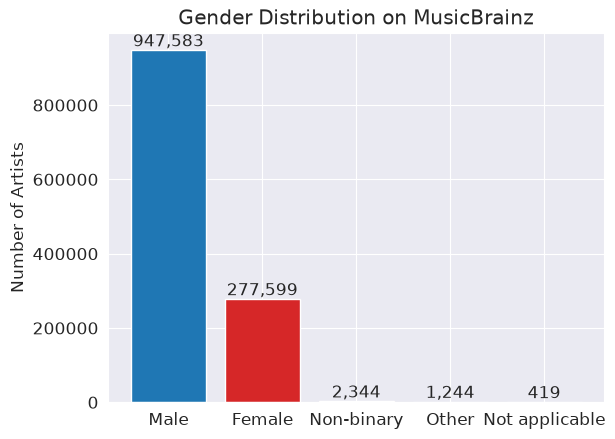

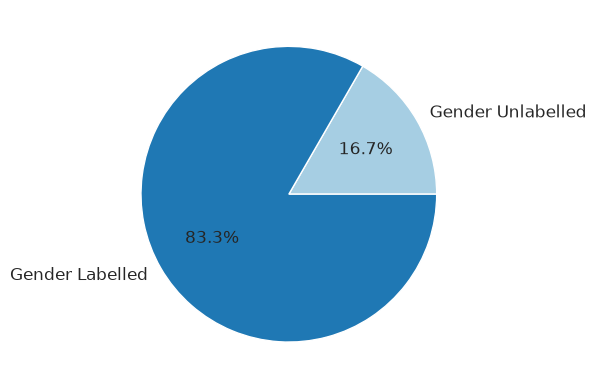

In [147]:
#What is the gender split like for the entities
genderCount = artistDF.select(pl.col("gender").value_counts(sort=True)).unnest("gender")
genderCountPercent = artistDF.select(pl.col("gender").value_counts(sort=True, normalize=True, name="Fraction")).unnest("gender")
print(genderCount)
genderChart = (
    alt.Chart(genderCount).mark_bar().encode(
    y="count",
    x="gender",
    )
    .properties(width=500, title="Gender Distribution of Music Brainz")
)
genderChart.encoding.x.title = "Genders"
genderChart.encoding.y.title = "Counts"
genderChart.show()

genderCountNoNulls = genderCount.drop_nulls()
plt.rc('font', size=12)
makeBarChart(genderCountNoNulls["gender"], genderCountNoNulls["count"], "Gender Distribution on MusicBrainz", "Number of Artists")

makePieChart(["Gender Unlabelled", "Gender Labelled"], [len (genderCount) - len(genderCountNoNulls), len(genderCountNoNulls)],  "", "Paired")


In [148]:
print(genderCountPercent)

shape: (6, 2)
┌────────────────┬──────────┐
│ gender         ┆ Fraction │
│ ---            ┆ ---      │
│ str            ┆ f64      │
╞════════════════╪══════════╡
│ Male           ┆ 0.60179  │
│ null           ┆ 0.219368 │
│ Female         ┆ 0.176297 │
│ Non-binary     ┆ 0.001489 │
│ Other          ┆ 0.00079  │
│ Not applicable ┆ 0.000266 │
└────────────────┴──────────┘


Overwhelmingly, the dataset skews towards men with ~60.2% of the dataset being men. More individuals do not have their gender attributed to them than female individuals.

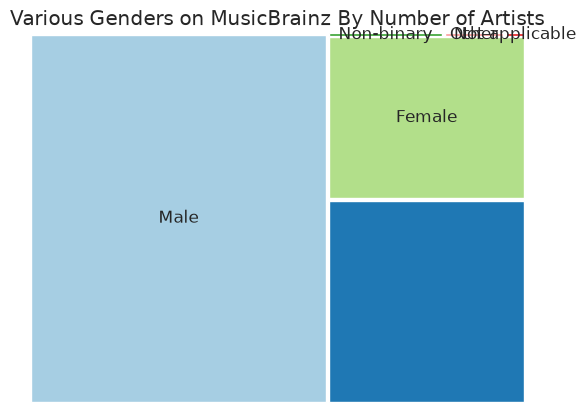

In [149]:
#Make a treemap of the genders
genderCountNoNulls = genderCount.drop_nulls()
makeTreeMap(genderCount["gender"], genderCount["count"], "Paired", "Various Genders on MusicBrainz By Number of Artists", pad=1 )

In [150]:
artistDFPandas = artistDF.to_pandas(use_pyarrow_extension_array=True)
artistDFPandas['genreList'] = artistDFPandas['genres'].map(prettifyGenres)
display(artistDFPandas.head(5))
display(artistDFPandas[artistDFPandas.name == "Madonna"])
artistDF = pl.from_pandas(artistDFPandas)
madonna = artistDF.filter(pl.col("name") == "Madonna")
display(madonna.head(5))


,id,name,type,gender,country,genres,isnis,ipis,life-span,genreList
0,3830382e-d3ad-41b2-8024-6f1fe424bc5b,Shaun Frank,Person,Male,CA,[{'id': '3976e9ba-16d0-461d-b732-99408a0374ba'...,['0000000465191733'],['00277516832'],"{'end': None, 'begin': '1982-06-07', 'ended': ...","[edm, electronic, house]"
1,53a04512-6ac2-47f0-a22c-260be441eba5,SUBZEROSWIZ,Person,Male,US,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
2,4a50b586-7bb3-476b-9333-d8b3da871158,NAOKI in the MERCURE,Person,Male,<NA>,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
3,24b3c8e7-3e48-48a5-97a8-3e098b3c0964,Alexandros Markopoulos,Person,Male,<NA>,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
4,8cd6d87c-38e7-4c28-8ad9-e476dd343c84,Yiannis Koutselinis,Person,Male,GR,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]


,id,name,type,gender,country,genres,isnis,ipis,life-span,genreList
1014724,79239441-bfd5-4981-a70c-55c3f15c1287,Madonna,Person,Female,US,[{'id': '930ef127-3653-4677-9b95-ecc90c7c1a14'...,['000000010782262X'],['00125053706' '00128246872' '00211854787'],"{'end': None, 'begin': '1958-08-16', 'ended': ...","[art pop, bubblegum pop, club, contemporary r&..."
1114484,3fd13140-6857-489a-9e53-a4e112b8354b,Madonna,Person,Female,LB,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]


id,name,type,gender,country,genres,isnis,ipis,life-span,genreList
str,str,str,str,str,list[struct[4]],list[str],list[str],struct[3],list[str]
"""79239441-bfd5-4981-a70c-55c3f1…","""Madonna""","""Person""","""Female""","""US""","[{""930ef127-3653-4677-9b95-ecc90c7c1a14"",7,"""",""art pop""}, {""6fd83b83-9b63-47fa-a208-5f9e762f40ab"",1,"""",""bubblegum pop""}, … {""45eb1d9c-588c-4dc8-9394-a14b7c8f02bc"",1,"""",""trip hop""}]","[""000000010782262X""]","[""00125053706"", ""00128246872"", ""00211854787""]","{null,""1958-08-16"",false}","[""art pop"", ""bubblegum pop"", … ""trip hop""]"
"""3fd13140-6857-489a-9e53-a4e112…","""Madonna""","""Person""","""Female""","""LB""",[],[],[],"{null,null,false}",[]


In [151]:
#Save the artist parquet now for network use
artistDF.write_parquet("./Data/Network_personMBData.parquet")

In [152]:
#Get the most common genre

idGenre = artistDF.select(
    pl.col("id"),
    pl.col("name"),
    pl.col("gender"),
    pl.col("genreList").alias("Genre"),
)

idGenre = idGenre.explode("Genre", empty_as_null=True, keep_nulls=True)
idGenre = idGenre.unique()
number_of_genres = idGenre.select(
    pl.col("Genre").value_counts(sort=True)
).unnest("Genre")
print(number_of_genres)


shape: (1_561, 2)
┌────────────────────────┬─────────┐
│ Genre                  ┆ count   │
│ ---                    ┆ ---     │
│ str                    ┆ u32     │
╞════════════════════════╪═════════╡
│ null                   ┆ 1481063 │
│ hip hop                ┆ 16678   │
│ jazz                   ┆ 12343   │
│ pop                    ┆ 8408    │
│ electronic             ┆ 6811    │
│ …                      ┆ …       │
│ power soca             ┆ 1       │
│ nueva canción española ┆ 1       │
│ bashment soca          ┆ 1       │
│ biguine                ┆ 1       │
│ loner folk             ┆ 1       │
└────────────────────────┴─────────┘


Most individuals do not have a genre attached to them based off of MusicBrainz's list of genres but the most popular genre is hip hop followed by Jazz music.

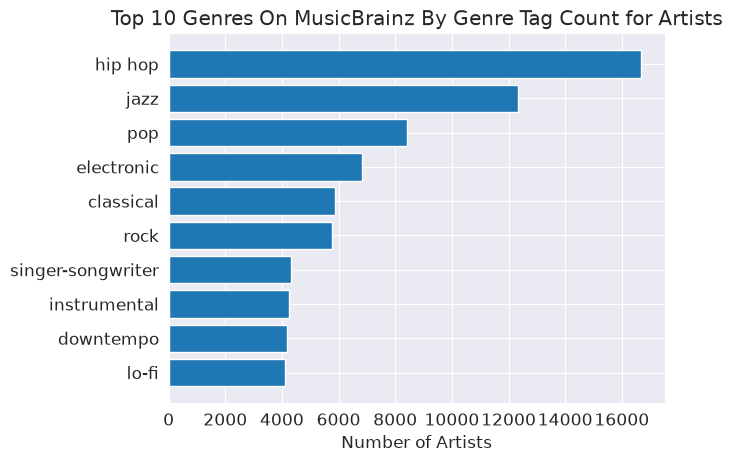

In [153]:
#Top genres
top10Genres = number_of_genres.drop_nulls()[0:10]
plt.rc('font', size=12)
horizontalBarChart(top10Genres["Genre"], top10Genres["count"], "Top 10 Genres On MusicBrainz By Genre Tag Count for Artists", "Number of Artists")

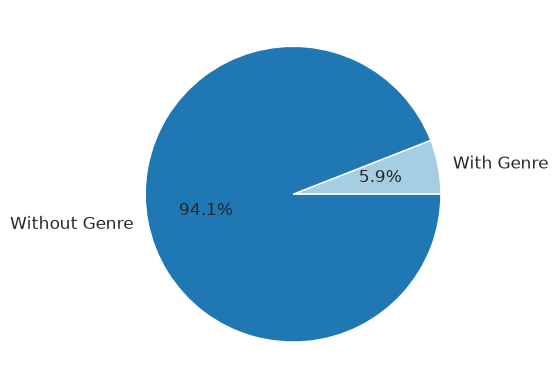

In [154]:
#Make a pie chart for people who have at least one genre and those who dont
noGenre = (idGenre
           .filter(
    pl.col("Genre").is_null(),
    ).select(pl.col("id")).drop_nulls().unique())
hasGenre = (idGenre
              .filter(
    pl.col("Genre").is_not_null(),
).select(pl.col("id")).drop_nulls().unique())
plt.rc('font', size=12)
makePieChart(["With Genre", "Without Genre"], [len(hasGenre), len(noGenre)],
             "Country Known vs Unknown on MusicBrainz for Groups", "Paired")

In [155]:
hasGenre

id
str
"""b3b04aa3-a1ae-4690-85f2-a25789…"
"""ccee75df-23ed-4e8e-bfd1-861dec…"
"""0abea2e2-41c1-49ac-8c2a-2adc7d…"
"""3e49f2ee-6939-4f9e-903a-c95fa4…"
"""48871254-4891-44dc-b238-8d41a1…"
…
"""fd228df7-f509-401e-869d-e22e33…"
"""aa147500-3131-4010-a2cc-1fb9cd…"
"""1f26ec56-6c31-4236-a876-64bf47…"


In [156]:
#Look for the gender and genre split using group by.
idGenre.group_by(["gender", 'Genre']).agg(pl.col('id').count())

gender,Genre,id
str,str,u32
"""Non-binary""","""blackgaze""",2
"""Male""","""shidaiqu""",3
null,"""plugg""",3
"""Female""","""canzone neomelodica""",1
"""Male""","""stoner rap""",1
…,…,…
"""Not applicable""","""industrial""",1
"""Female""","""hardcore hip hop""",11
"""Male""","""italo dance""",30


In [157]:
#Most common gender-country pair.
artistDF.group_by(["gender","country"]).agg(pl.col('id').count())

gender,country,id
str,str,u32
"""Female""","""FI""",3446
"""Male""","""DM""",26
"""Non-binary""","""RU""",14
"""Other""","""KZ""",1
null,"""MD""",12
…,…,…
"""Female""","""AL""",87
null,"""JO""",7
"""Female""","""DK""",1671
